In [4]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("sushant097/bank-marketing-dataset-full")

# print("Path to dataset files:", path)

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, learning_curve
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay, roc_auc_score
)


In [6]:
# load dataset downloaded from kaggle
df = pd.read_csv("bank-full.csv", sep=";")

In [7]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


In [9]:
# clean missing
df = df.replace("?", np.nan).dropna()

## Define target col

In [10]:
TARGET_COL = "y"

In [11]:
# Convert income labels to binary 0 or 1
y = df[TARGET_COL].astype(str).str.contains("yes").astype(int)

X = df.drop(columns=[TARGET_COL])

## Test/Train split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

## Preprocessing

In [13]:
numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = [c for c in X.columns if c not in numeric_cols]

numeric_preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_preprocess, numeric_cols),
        ("cat", categorical_preprocess, categorical_cols),
    ],
    remainder="drop"
)

## Model pipeline

In [14]:
clf = DecisionTreeClassifier(random_state=42)

pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", clf)
])

## Hyperparameter tuning (GridSearchCV)

In [15]:
param_grid = {
    "model__criterion": ["gini", "entropy"],
    "model__max_depth": [3, 5, 8, 10, 12, None],
    "model__min_samples_split": [2, 10, 50, 200],
    "model__min_samples_leaf": [1, 5, 20, 50],
    "model__ccp_alpha": [0.0, 0.0001, 0.001],  # cost-complexity pruning
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True
)

grid.fit(X_train, y_train)

Fitting 5 folds for each of 576 candidates, totalling 2880 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__ccp_alpha': [0.0, 0.0001, ...], 'model__criterion': ['gini', 'entropy'], 'model__max_depth': [3, 5, ...], 'model__min_samples_leaf': [1, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, th

In [16]:
print("\nBest parameters:")
print(grid.best_params_)
print("\nBest ac:")
print(grid.best_score_)


Best parameters:
{'model__ccp_alpha': 0.0001, 'model__criterion': 'gini', 'model__max_depth': 8, 'model__min_samples_leaf': 5, 'model__min_samples_split': 2}

Best ac:
0.9024550596729067


In [17]:
best_model = grid.best_estimator_

## Evaluation on test set

In [18]:
y_pred = best_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nTEST METRICS")
print(f"Accuracy: {acc:.4f}")
print(f"F1-score : {f1:.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=4))

# Some ROC/AUC metrics require probabilities
# Decision trees support predict_proba by default
y_proba = best_model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC  : {auc:.4f}")


TEST METRICS
Accuracy: 0.9034
F1-score : 0.4847

Classification report:
              precision    recall  f1-score   support

           0     0.9230    0.9717    0.9467     11977
           1     0.6450    0.3882    0.4847      1587

    accuracy                         0.9034     13564
   macro avg     0.7840    0.6799    0.7157     13564
weighted avg     0.8905    0.9034    0.8927     13564

ROC-AUC  : 0.8763


## Plots: Confusion matrix + ROC curve

<Figure size 640x480 with 0 Axes>

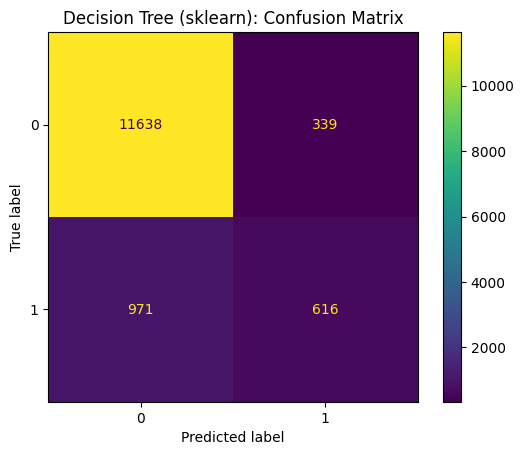

<Figure size 640x480 with 0 Axes>

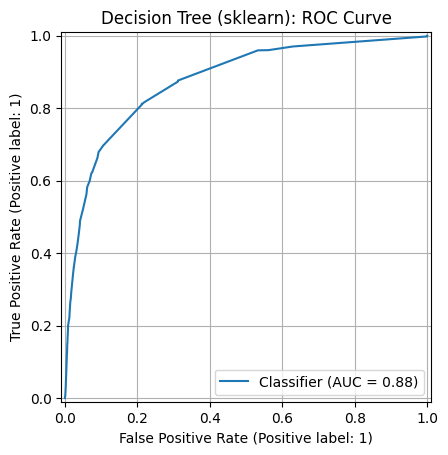

In [19]:
plt.figure()
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, values_format="d")
plt.title("Decision Tree (sklearn): Confusion Matrix")
plt.grid(False)
plt.savefig("sk_cm.png", bbox_inches="tight", dpi=200)
plt.show()

plt.figure()
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("Decision Tree (sklearn): ROC Curve")
plt.grid(True)
plt.savefig("sk_roc.png", bbox_inches="tight", dpi=200)
plt.show()


## Plot: Feature importances (top 20)

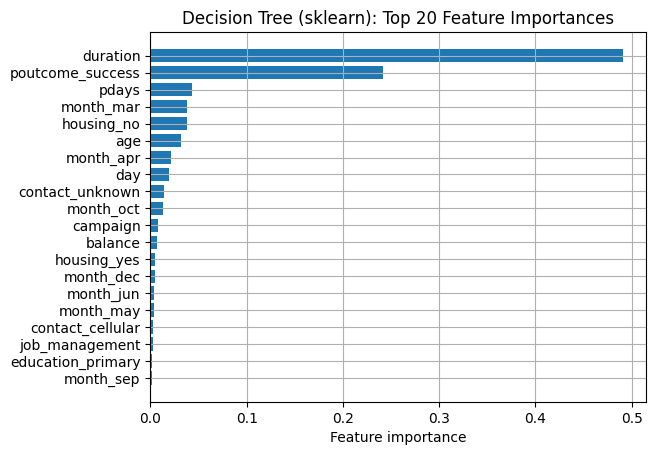

In [20]:
pre = best_model.named_steps["preprocess"]
ohe = pre.named_transformers_["cat"].named_steps["onehot"]

# Numeric names + one-hot names
num_names = numeric_cols
cat_names = ohe.get_feature_names_out(categorical_cols).tolist()
feature_names = num_names + cat_names

tree = best_model.named_steps["model"]
importances = tree.feature_importances_

# Safety: in rare cases, lengths can differ due to pipeline quirks; guard it
m = min(len(feature_names), len(importances))
feature_names = feature_names[:m]
importances = importances[:m]

top_k = 20
idx = np.argsort(importances)[-top_k:]

plt.figure()
plt.barh(np.array(feature_names)[idx], importances[idx])
plt.xlabel("Feature importance")
plt.title(f"Decision Tree (sklearn): Top {top_k} Feature Importances")
plt.grid(True)
plt.savefig("sk_feature_importance.png", bbox_inches="tight", dpi=200)
plt.show()

## Plot: Learning curve (diagnose under/overfitting)

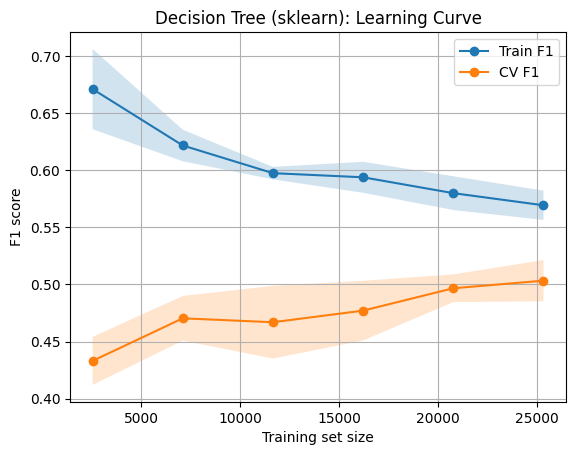

In [21]:
train_sizes, train_scores, val_scores = learning_curve(
    best_model,
    X_train, y_train,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 6),
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

plt.figure()
plt.plot(train_sizes, train_mean, marker="o", label="Train F1")
plt.plot(train_sizes, val_mean, marker="o", label="CV F1")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2)
plt.xlabel("Training set size")
plt.ylabel("F1 score")
plt.title("Decision Tree (sklearn): Learning Curve")
plt.grid(True)
plt.legend()
plt.savefig("sk_learning_curve.png", bbox_inches="tight", dpi=200)
plt.show()

## Numpy Tree

In [22]:
class _Node:
    __slots__ = ("feature", "threshold", "left", "right", "is_leaf","proba", "pred")
    def __init__(self, *, feature=None, threshold=None, left=None, right=None,
                 is_leaf=False, proba=None, pred=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.is_leaf = is_leaf
        self.proba = proba
        self.pred = pred


In [23]:
class NumpyTreeClassifier:
    """
    A NumPy-only decision tree for classification.
    """
    def __init__(self, criterion="gini", max_depth=None, min_samples_split=2,
                 min_samples_leaf=1, min_gain = 0.0, random_state=None):
        
        # Values will be inherited from gridsearch results.

        if criterion not in ("gini", "entropy"):
            raise ValueError("criterion must be either 'gini' or 'entropy'")
        self.criterion = criterion
        self.max_depth = max_depth
        self.min_samples_split = int(min_samples_split)
        self.min_samples_leaf = int(min_samples_leaf)
        self.min_gain = float(min_gain)
        self.random_state = random_state

        self.classes_ = None
        self.n_classes_ = None
        self.root_ = None

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)

        self.classes_, y_enc = np.unique(y, return_inverse=True)
        self.n_classes_ = len(self.classes_)

        self.root_ = self._grow(X, y_enc, depth=0) 

        return self

    def predict(self, X):
        X = np.asarray(X)
        preds_enc = np.array([self._predict_one(x, self.root_) for x in X], dtype=int)
        return self.classes_[preds_enc]

    def predict_proba(self, X):
        X = np.asarray(X)
        out = np.zeros((X.shape[0], self.n_classes_), dtype=float)
        for i, x in enumerate(X):
            node = self.root_
            while not node.is_leaf:
                if x[node.feature] <= node.threshold:
                    node = node.left
                else:
                    node = node.right
            out[i] = node.proba
        return out

    # ---------- internals ----------
    def _impurity_from_counts(self, counts):
        n = counts.sum()
        if n <= 0:
            return 0.0
        p = counts / n
        if self.criterion == "gini":
            return 1.0 - np.sum(p * p)
        # entropy
        p = p[p > 0]
        return -np.sum(p * np.log2(p))

    def _best_split(self, X, y):
        n, d = X.shape
        if n < self.min_samples_split:
            return None, None, None

        parent_counts = np.bincount(y, minlength=self.n_classes_)
        parent_impurity = self._impurity_from_counts(parent_counts)
        if parent_impurity == 0.0:
            return None, None, None

        best_gain = 0.0
        best_feat = None
        best_thr = None
        best_mask = None

        for j in range(d):
            xj = X[:, j]

            # Sort samples by this feature
            order = np.argsort(xj, kind="quicksort")
            x_sorted = xj[order]
            y_sorted = y[order]

            # If feature is constant -> skip
            if x_sorted[0] == x_sorted[-1]:
                continue

            left_counts = np.zeros(self.n_classes_, dtype=int)
            right_counts = parent_counts.copy()

            # Consider split points between distinct feature values
            # We update counts incrementally as we move the split.
            for i in range(0, n - 1):
                c = y_sorted[i]
                left_counts[c] += 1
                right_counts[c] -= 1

                # Ensure both sides meet min_samples_leaf
                left_n = i + 1
                right_n = n - left_n
                if left_n < self.min_samples_leaf or right_n < self.min_samples_leaf:
                    continue

                # Only split if next value differs (valid threshold between)
                if x_sorted[i] == x_sorted[i + 1]:
                    continue

                left_imp = self._impurity_from_counts(left_counts)
                right_imp = self._impurity_from_counts(right_counts)

                # Information gain
                weighted = (left_n / n) * left_imp + (right_n / n) * right_imp
                gain = parent_impurity - weighted

                if gain > best_gain:
                    best_gain = gain
                    best_feat = j
                    best_thr = 0.5 * (x_sorted[i] + x_sorted[i + 1])

        # "Easy pruning": require minimum gain to split
        if best_feat is None or best_gain <= self.min_gain:
            return None, None, None

        mask = X[:, best_feat] <= best_thr
        return best_feat, best_thr, mask

    def _grow(self, X, y, depth):
        counts = np.bincount(y, minlength=self.n_classes_)
        n = y.size
        proba = counts / n
        pred = int(np.argmax(counts))

        impurity = self._impurity_from_counts(counts)

        if (self.max_depth is not None and depth >= self.max_depth) or \
           n < self.min_samples_split or \
           impurity == 0.0:
            return _Node(is_leaf=True, proba=proba, pred=pred)

        feat, thr, mask = self._best_split(X, y)
        if feat is None:
            return _Node(is_leaf=True, proba=proba, pred=pred)

        left = self._grow(X[mask], y[mask], depth + 1)
        right = self._grow(X[~mask], y[~mask], depth + 1)
        return _Node(feature=feat, threshold=thr, left=left, right=right,
                     is_leaf=False, proba=proba, pred=pred)

    def _predict_one(self, x, node):
        while not node.is_leaf:
            node = node.left if x[node.feature] <= node.threshold else node.right
        return node.pred

In [24]:
from sklearn.base import BaseEstimator, ClassifierMixin ,TransformerMixin

class SKCompatibleNumpyTree(BaseEstimator, ClassifierMixin):
    def __init__(self, criterion="gini", max_depth=None,
                 min_samples_split=2, min_samples_leaf=1,
                 min_gain=0.0, random_state=None):
        self.criterion = criterion
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.min_gain = min_gain
        self.random_state = random_state
        self._model = None

    def fit(self, X, y):
        # use the numpy tree as the underlying model.
        self._model = NumpyTreeClassifier(
            criterion=self.criterion,
            max_depth=self.max_depth,
            min_samples_split=self.min_samples_split,
            min_samples_leaf=self.min_samples_leaf,
            min_gain=self.min_gain,
            random_state=self.random_state
        )
        self._model.fit(X, y)
        self.classes_ = self._model.classes_
        return self

    def predict(self, X):
        return self._model.predict(X)

    def predict_proba(self, X):
        return self._model.predict_proba(X)

class ToDense(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None): 
        return self
    def transform(self, X):
        return X.toarray() if hasattr(X, "toarray") else np.asarray(X)

## GridSearch on NumpyTree

In [25]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import f1_score

pipe_np = Pipeline([
    ("preprocess", preprocess),
    ("todense", ToDense()),
    ("model", SKCompatibleNumpyTree(random_state=42))
])

labels = np.unique(y)
pos_label = "yes" if "yes" in labels else (labels[1] if len(labels) == 2 else None)

param_grid = {    
    "model__criterion": ["gini", "entropy"],
    "model__max_depth": [3, 5, 8, 10, 12, None],
    "model__min_samples_split": [2, 10, 50, 200],
    "model__min_samples_leaf": [1, 5, 20, 50],
    "model__min_gain": [0.0, 0.0001, 0.001]

}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_np = GridSearchCV(
    pipe_np,
    param_grid=param_grid,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=1
)

grid_np.fit(X_train, y_train)

print("Best params:", grid_np.best_params_)
print("Best CV score:", grid_np.best_score_)
best_numpy_tree = grid_np.best_estimator_

Fitting 3 folds for each of 576 candidates, totalling 1728 fits
Best params: {'model__criterion': 'entropy', 'model__max_depth': 5, 'model__min_gain': 0.0, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}
Best CV score: 0.9012860618700035


In [26]:
pred = best_numpy_tree.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

# If binary labels are strings, pick the positive label safely:
labels = np.unique(y_test)
pos_label = labels[-1] 
print("F1:", f1_score(y_test, pred, pos_label=pos_label))

Accuracy: 0.8994396933058095
F1: 0.4017543859649123


In [27]:
proba = best_numpy_tree.predict_proba(X_test)[:,1]

In [28]:
sk_pred = y_pred
sk_proba = y_proba

np_pred = pred
np_proba = proba

# ----------------------------
# Metrics table
# ----------------------------

In [29]:
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, precision_recall_curve, average_precision_score
)

In [30]:
def compute_metrics(y_true, y_pred, pos_label=None):
    out = {}
    out["accuracy"] = accuracy_score(y_true, y_pred)

    if pos_label is not None:
        out["f1"] = f1_score(y_true, y_pred, pos_label=pos_label)
        out["precision"] = precision_score(y_true, y_pred, pos_label=pos_label)
        out["recall"] = recall_score(y_true, y_pred, pos_label=pos_label)
    else:
        # multiclass: use macro averaging
        out["f1"] = f1_score(y_true, y_pred, average="macro")
        out["precision"] = precision_score(y_true, y_pred, average="macro")
        out["recall"] = recall_score(y_true, y_pred, average="macro")
    return out

sk_metrics = compute_metrics(y_test, sk_pred, pos_label=pos_label)
np_metrics = compute_metrics(y_test, np_pred, pos_label=pos_label)

print("Sklearn tree metrics:", sk_metrics)
print("NumPy tree metrics:  ", np_metrics)

Sklearn tree metrics: {'accuracy': 0.903420819817163, 'f1': 0.4846577498033045, 'precision': 0.6450261780104712, 'recall': 0.38815374921235035}
NumPy tree metrics:   {'accuracy': 0.8994396933058095, 'f1': 0.4017543859649123, 'precision': 0.6608946608946609, 'recall': 0.2885948330182735}


# ----------------------------
# Metric comparison bar plot
# ----------------------------

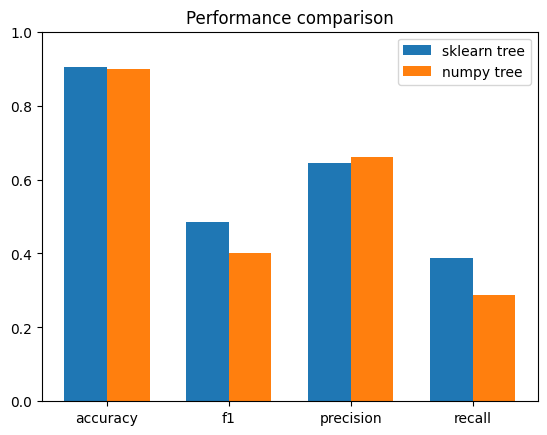

In [31]:
metric_names = ["accuracy", "f1", "precision", "recall"]
sk_vals = [sk_metrics[m] for m in metric_names]
np_vals = [np_metrics[m] for m in metric_names]

x = np.arange(len(metric_names))
width = 0.35

plt.figure()
plt.bar(x - width/2, sk_vals, width, label="sklearn tree")
plt.bar(x + width/2, np_vals, width, label="numpy tree")
plt.xticks(x, metric_names)
plt.ylim(0, 1.0)
plt.title("Performance comparison")
plt.legend()
plt.savefig("performance_comparison.png", bbox_inches="tight", dpi=200)
plt.show()


# ----------------------------
# Confusion matrices (side-by-side)
# ----------------------------

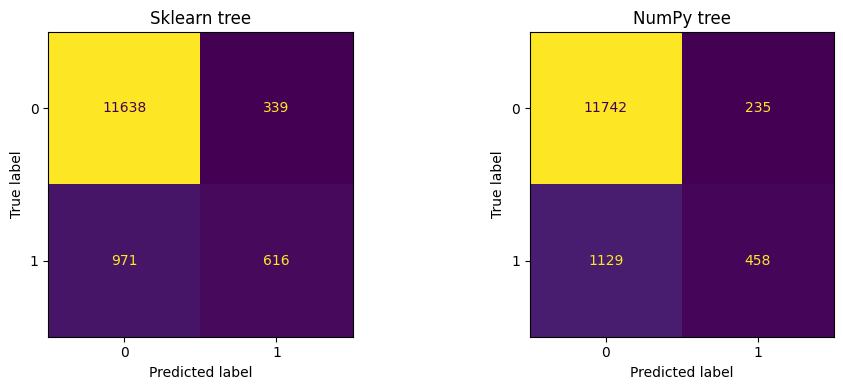

In [32]:
cm_sk = confusion_matrix(y_test, sk_pred, labels=labels)
cm_np = confusion_matrix(y_test, np_pred, labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay(cm_sk, display_labels=labels).plot(ax=axes[0], values_format="d", colorbar=False)
axes[0].set_title("Sklearn tree")

ConfusionMatrixDisplay(cm_np, display_labels=labels).plot(ax=axes[1], values_format="d", colorbar=False)
axes[1].set_title("NumPy tree")

plt.tight_layout()
plt.savefig("confusion_matrices.png", bbox_inches="tight", dpi=200)
plt.show()


# ----------------------------
# ROC + PR curves
# ----------------------------

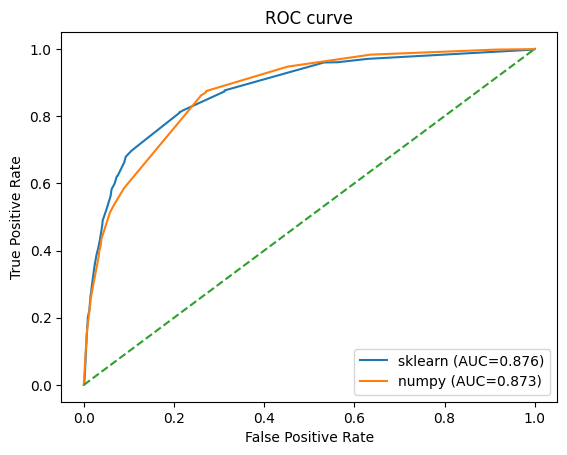

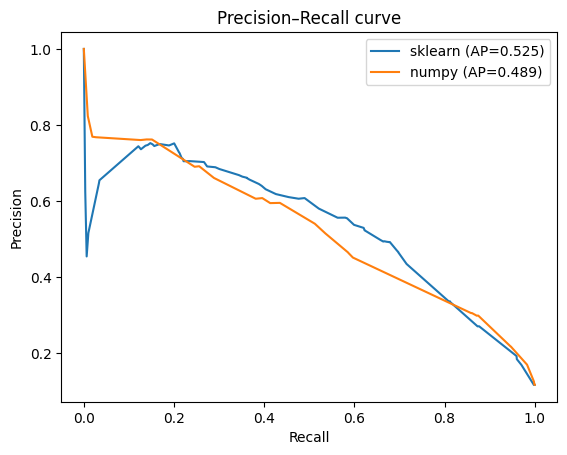

In [33]:
def proba_for_pos(proba, classes, pos_label, assume_pos_index=1):
    """
    Return a 1D array of scores for the positive class.

    - If proba is 2D (n_samples, n_classes): return the column matching pos_label.
    - If proba is 1D (n_samples,): assume it already represents P(pos_label).
      (common when you do predict_proba(...)[:, 1])
    """
    proba = np.asarray(proba)

    # Case 1: already a 1D vector of positive-class probabilities/scores
    if proba.ndim == 1:
        return proba

    # Case 2: normal predict_proba matrix
    if proba.ndim == 2:
        # If we can map by label, do it
        if classes is not None:
            classes = np.asarray(classes)
            idx = np.where(classes == pos_label)[0]
            if idx.size == 1:
                return proba[:, int(idx[0])]

        # Fallback: assume positive is column 1
        if proba.shape[1] <= assume_pos_index:
            raise ValueError(f"proba has shape {proba.shape}, can't take column {assume_pos_index}.")
        return proba[:, assume_pos_index]

    raise ValueError(f"Unexpected proba shape: {proba.shape}")

# sklearn classes (from final estimator in pipeline)
sk_classes = best_model.named_steps["model"].classes_
np_classes = best_numpy_tree.named_steps["model"]._model.classes_

y_true_bin = (np.asarray(y_test) == pos_label).astype(int)

sk_pos = proba_for_pos(sk_proba, sk_classes, pos_label)
np_pos = proba_for_pos(np_proba, np_classes, pos_label)

# ROC
fpr_sk, tpr_sk, _ = roc_curve(y_true_bin, sk_pos)
fpr_np, tpr_np, _ = roc_curve(y_true_bin, np_pos)

auc_sk = auc(fpr_sk, tpr_sk)
auc_np = auc(fpr_np, tpr_np)

plt.figure()
plt.plot(fpr_sk, tpr_sk, label=f"sklearn (AUC={auc_sk:.3f})")
plt.plot(fpr_np, tpr_np, label=f"numpy (AUC={auc_np:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve")
plt.legend()
plt.savefig("ROC_curve.png", bbox_inches="tight", dpi=200)
plt.show()

# Precision-Recall
prec_sk, rec_sk, _ = precision_recall_curve(y_true_bin, sk_pos)
prec_np, rec_np, _ = precision_recall_curve(y_true_bin, np_pos)

ap_sk = average_precision_score(y_true_bin, sk_pos)
ap_np = average_precision_score(y_true_bin, np_pos)

plt.figure()
plt.plot(rec_sk, prec_sk, label=f"sklearn (AP={ap_sk:.3f})")
plt.plot(rec_np, prec_np, label=f"numpy (AP={ap_np:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall curve")
plt.legend()
plt.savefig("PR_curve.png", bbox_inches="tight", dpi=200)
plt.show()


# ----------------------------
# Tree complexity comparison (depth + node count)
# ----------------------------

Sklearn tree: nodes=151, depth=8
NumPy tree:   nodes=61, depth=6


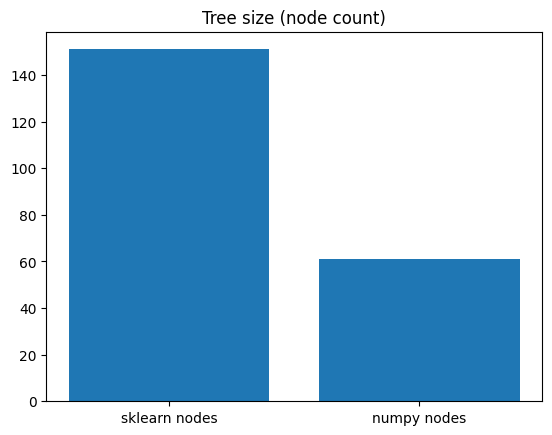

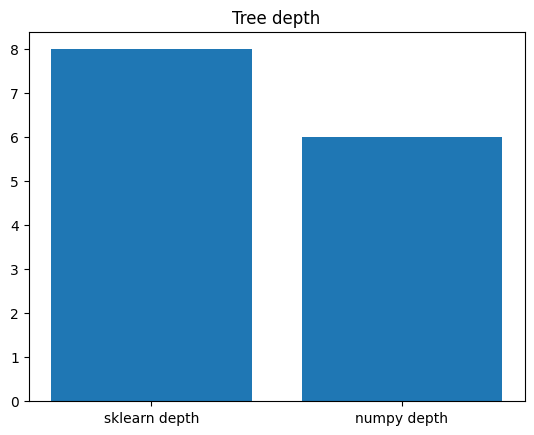

In [34]:
# sklearn tree stats
sk_tree = best_model.named_steps["model"].tree_
sk_node_count = sk_tree.node_count
sk_depth = best_model.named_steps["model"].get_depth()

# numpy tree stats (helpers)
def numpy_tree_node_count(node):
    if node is None:
        return 0
    if node.is_leaf:
        return 1
    return 1 + numpy_tree_node_count(node.left) + numpy_tree_node_count(node.right)

def numpy_tree_depth(node):
    if node is None:
        return 0
    if node.is_leaf:
        return 1
    return 1 + max(numpy_tree_depth(node.left), numpy_tree_depth(node.right))

np_node_count = numpy_tree_node_count(best_numpy_tree.named_steps["model"]._model.root_)
np_depth = numpy_tree_depth(best_numpy_tree.named_steps["model"]._model.root_)

print(f"Sklearn tree: nodes={sk_node_count}, depth={sk_depth}")
print(f"NumPy tree:   nodes={np_node_count}, depth={np_depth}")

plt.figure()
plt.bar(["sklearn nodes", "numpy nodes"], [sk_node_count, np_node_count])
plt.title("Tree size (node count)")
plt.savefig("tree_size.png", bbox_inches="tight", dpi=200)
plt.show()

plt.figure()
plt.bar(["sklearn depth", "numpy depth"], [sk_depth, np_depth])
plt.title("Tree depth")
plt.savefig("tree_depth.png", bbox_inches="tight", dpi=200)
plt.show()

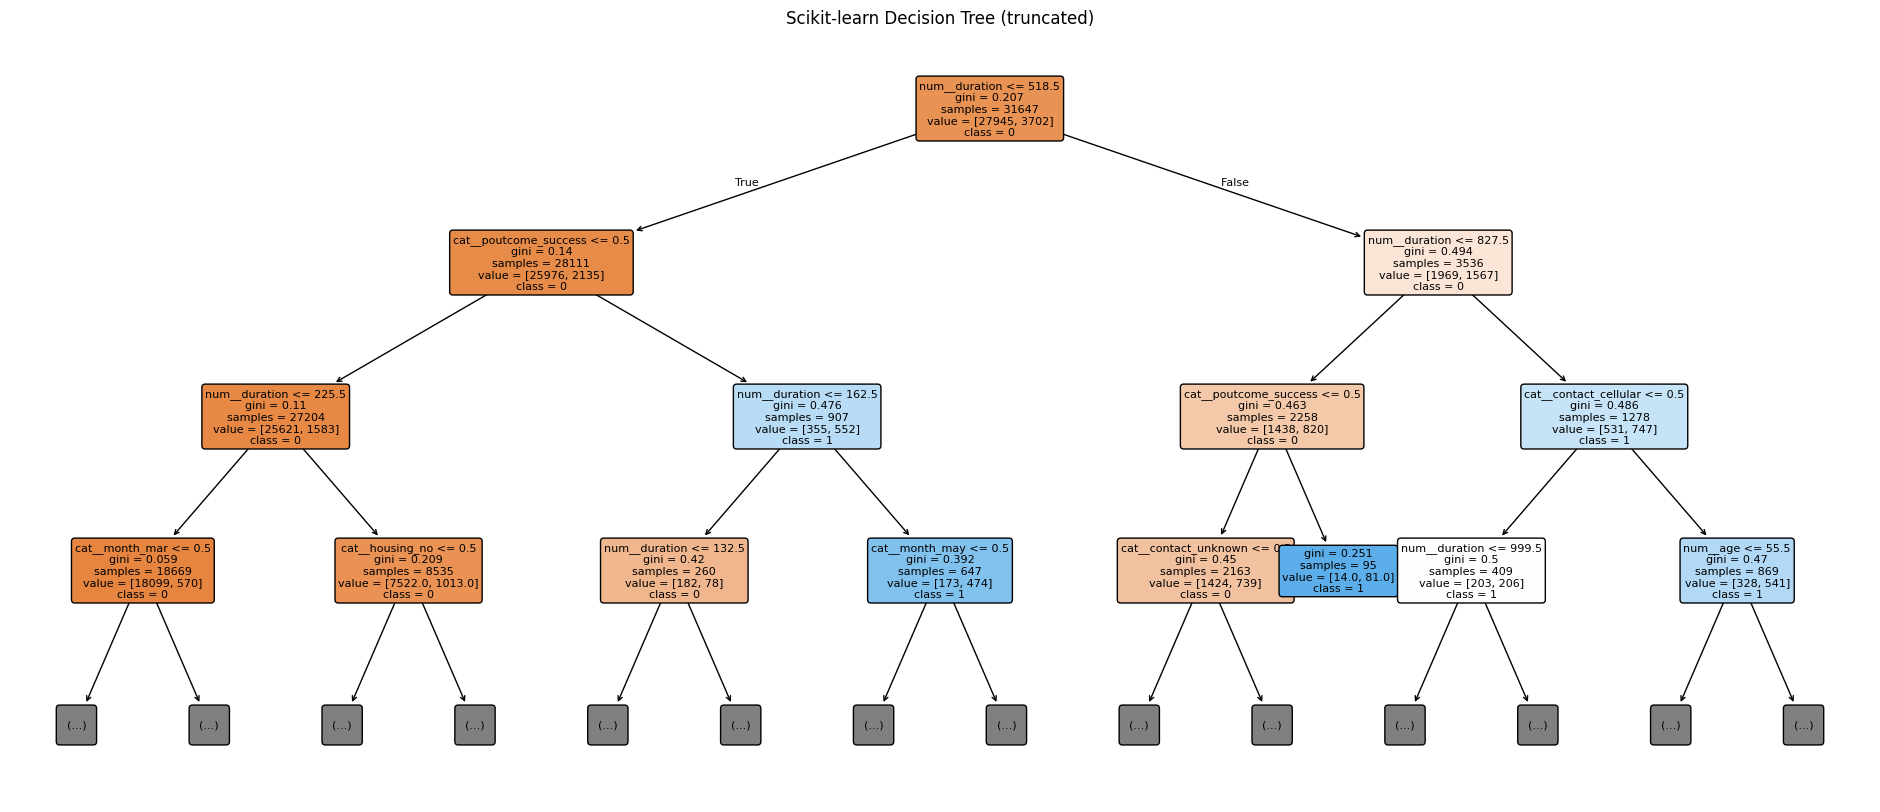

In [35]:
from sklearn.tree import plot_tree

# fitted pipeline
pre = best_model.named_steps["preprocess"]
sk_tree_model = best_model.named_steps["model"]

# try to extract post-preprocess feature names (works for sklearn>=1.0)
try:
    feature_names = pre.get_feature_names_out()
except Exception:
    feature_names = None

plt.figure(figsize=(24, 10))
plot_tree(
    sk_tree_model,
    feature_names=feature_names,
    class_names=[str(c) for c in sk_tree_model.classes_],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)
plt.title("Scikit-learn Decision Tree (truncated)")
plt.savefig("sk_tree.png", bbox_inches="tight", dpi=200)
plt.show()

In [36]:
def export_numpy_tree_to_dot(ntree, feature_names=None, class_names=None, max_depth=None):
    """
    ntree: your NumpyTreeClassifier instance (or the core one inside wrapper)
    feature_names: list/array of feature names (len = n_features)
    class_names: list of class name strings (len = n_classes)
    max_depth: int or None (truncate display)

    Returns: DOT string
    """
    if class_names is None:
        class_names = [str(c) for c in ntree.classes_]

    if feature_names is None:
        feature_names = [f"x{i}" for i in range(getattr(ntree, "n_features_", 0) or 10**9)]

    lines = ["digraph Tree {", 'node [shape=box, style="rounded,filled", fontname="helvetica"];']
    node_id = 0

    def node_label(node):
        # Leaf: show predicted class + probs
        if node.is_leaf:
            probs = np.round(node.proba, 3)
            pred = class_names[int(node.pred)]
            return f"leaf\\npred={pred}\\nproba={probs}"
        # Internal: show split
        fname = feature_names[node.feature] if node.feature < len(feature_names) else f"x{node.feature}"
        return f"{fname} <= {node.threshold:.6g}"

    def recurse(node, depth):
        nonlocal node_id
        my_id = node_id
        node_id += 1

        # truncate?
        if max_depth is not None and depth >= max_depth and not node.is_leaf:
            # show as leaf-ish summary at cutoff
            probs = np.round(node.proba, 3)
            pred = class_names[int(node.pred)]
            lbl = f"cutoff\\npred={pred}\\nproba={probs}"
            lines.append(f'{my_id} [label="{lbl}", fillcolor="#eeeeee"];')
            return my_id

        lbl = node_label(node)
        fill = "#e8f5e9" if node.is_leaf else "#e3f2fd"
        lines.append(f'{my_id} [label="{lbl}", fillcolor="{fill}"];')

        if not node.is_leaf:
            left_id = recurse(node.left, depth + 1)
            right_id = recurse(node.right, depth + 1)
            lines.append(f"{my_id} -> {left_id} [label=\"True\"];")
            lines.append(f"{my_id} -> {right_id} [label=\"False\"];")

        return my_id

    recurse(ntree.root_, 0)
    lines.append("}")
    return "\n".join(lines)

In [37]:
# get post-preprocess feature names from the SAME preprocess used in the numpy pipeline
pre_np = best_numpy_tree.named_steps["preprocess"]
try:
    feature_names_np = pre_np.get_feature_names_out()
except Exception:
    feature_names_np = None

numpy_core = best_numpy_tree.named_steps["model"]._model
dot = export_numpy_tree_to_dot(
    numpy_core,
    feature_names=feature_names_np,
    class_names=[str(c) for c in numpy_core.classes_],
    max_depth=3   # truncate for readability
)

with open("numpy_tree.dot", "w", encoding="utf-8") as f:
    f.write(dot)

print("Wrote numpy_tree.dot")

Wrote numpy_tree.dot
